In [11]:
import numpy as np
import pandas as pd

In [12]:
df = pd.read_csv("DateFruit_Dataset.csv")

In [13]:
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [14]:
df.isnull().sum()

AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
MeanRR           0
MeanRG           0
MeanRB           0
StdDevRR         0
StdDevRG         0
StdDevRB         0
SkewRR           0
SkewRG           0
SkewRB           0
KurtosisRR       0
KurtosisRG       0
KurtosisRB       0
EntropyRR        0
EntropyRG        0
EntropyRB        0
ALLdaub4RR       0
ALLdaub4RG       0
ALLdaub4RB       0
Class            0
dtype: int64

In [23]:
df['Class'].nunique()

7

In [24]:
df['Class'].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [15]:
X = df.drop(columns=['Class'])
y = df['Class']

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [29]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [30]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [31]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [37]:
# Building ANN model

class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # Hidden layer 1
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),

            # Hidden Layer 2
            nn.Linear(64, 64),
            nn.ReLU(),

            # Output layer
            nn.Linear(64, 7)
            # no need to explicitly mention softmax since we are using cross entropy loss fnx
            # the softmax is by default used
        )
    def forward(self, x):
        return self.model(x)

In [38]:
model = ANN()
# loss, optim
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [39]:
# Training ANN

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criteria(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    train_loss = running_loss/len(train_loader)
    print(f"{epoch+1}/{100}: {train_loss}")

1/100: 1.8406059344609578
2/100: 1.53795591990153
3/100: 1.2075605342785518
4/100: 0.9370259344577789
5/100: 0.7496972680091858
6/100: 0.6372997363408407
7/100: 0.5329662635922432
8/100: 0.492834967871507
9/100: 0.4395049264033635
10/100: 0.415622611840566
11/100: 0.3656235858798027
12/100: 0.33691606546441716
13/100: 0.33050092682242393
14/100: 0.2898294124752283
15/100: 0.28837185477217037
16/100: 0.27074236050248146
17/100: 0.2570408682028453
18/100: 0.23457122594118118
19/100: 0.22895942255854607
20/100: 0.22530564417441687
21/100: 0.21864035166800022
22/100: 0.19671534126003584
23/100: 0.1966679518421491
24/100: 0.1834770863254865
25/100: 0.18230785864094892
26/100: 0.1851995506634315
27/100: 0.16856545644501844
28/100: 0.16903714338938394
29/100: 0.1673067882657051
30/100: 0.18141192135711512
31/100: 0.15626111440360546
32/100: 0.15426215715706348
33/100: 0.147830410550038
34/100: 0.14109858218580484
35/100: 0.13939124532043934
36/100: 0.13367271578560272
37/100: 0.13204434917618

In [46]:
# Evaluate
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _,predicted = torch.max(outputs, 1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)
        print(f"{yb.shape}")
        print(f"{outputs.shape}")
        print(predicted)
print(f"correct:{correct}\ntotal:{total}")

torch.Size([64])
torch.Size([64, 7])
tensor([2, 5, 2, 6, 0, 2, 3, 2, 2, 1, 1, 2, 2, 2, 4, 4, 6, 5, 6, 1, 5, 4, 2, 4,
        5, 2, 3, 6, 0, 5, 6, 1, 2, 4, 2, 5, 0, 2, 2, 5, 1, 4, 5, 5, 1, 1, 1, 2,
        2, 5, 3, 0, 2, 6, 2, 4, 6, 2, 2, 0, 3, 6, 2, 2])
torch.Size([64])
torch.Size([64, 7])
tensor([2, 6, 1, 2, 4, 4, 2, 2, 4, 6, 3, 4, 2, 4, 5, 4, 2, 1, 4, 4, 2, 4, 2, 5,
        3, 2, 2, 5, 5, 3, 1, 2, 2, 2, 2, 4, 4, 3, 2, 5, 5, 4, 3, 4, 4, 2, 5, 2,
        4, 4, 4, 6, 1, 5, 5, 4, 4, 2, 5, 1, 5, 5, 6, 1])
torch.Size([52])
torch.Size([52, 7])
tensor([4, 4, 2, 1, 3, 4, 4, 2, 4, 2, 5, 0, 5, 5, 5, 1, 6, 5, 2, 0, 0, 5, 6, 4,
        6, 1, 6, 5, 6, 1, 2, 3, 5, 2, 6, 5, 0, 0, 2, 4, 2, 4, 1, 6, 5, 6, 6, 5,
        0, 1, 0, 2])
correct:173
total:180


In [48]:
print(f"accuracy: {correct/total * 100}")

accuracy: 96.11111111111111


In [50]:
# PCA ==> DIMENSIONALITY REDUCTION
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train_scaled)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[4.09923373e-01 2.29855658e-01 1.13876290e-01 6.25712922e-02
 4.99146274e-02 3.67911865e-02 2.67421054e-02 1.82848920e-02
 1.47970047e-02 7.93891390e-03 6.45975478e-03 4.83848005e-03
 4.00066264e-03 3.40697244e-03 2.70389726e-03 2.07777136e-03
 1.37413611e-03 1.30503529e-03 1.16219835e-03 7.46939441e-04
 5.19520108e-04 3.68038547e-04 1.57024935e-04 1.11095314e-04
 3.76091580e-05 2.06956574e-05 9.47064117e-06 3.22875301e-06
 1.88819432e-06 1.97138697e-07 3.91308896e-08 1.38498467e-09
 1.21714347e-10 4.56624449e-11]


In [51]:
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.40992337 0.63977903 0.75365532 0.81622661 0.86614124 0.90293243
 0.92967453 0.94795942 0.96275643 0.97069534 0.9771551  0.98199358
 0.98599424 0.98940121 0.99210511 0.99418288 0.99555702 0.99686205
 0.99802425 0.99877119 0.99929071 0.99965875 0.99981577 0.99992687
 0.99996448 0.99998517 0.99999465 0.99999787 0.99999976 0.99999996
 1.         1.         1.         1.        ]


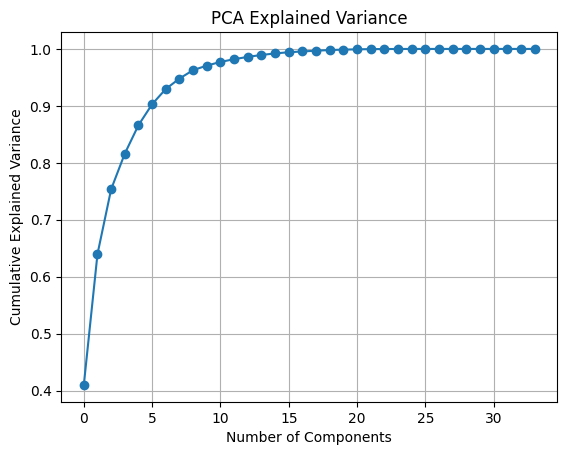

In [52]:
import matplotlib.pyplot as plt

plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [106]:
# PCA ==> DIMENSIONALITY REDUCTION
from sklearn.decomposition import PCA
pca = PCA(n_components=25)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.transform(X_test_scaled)


In [107]:
X_train_reduced.shape

(718, 25)

In [108]:
X_train_tensor = torch.tensor(X_train_reduced, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_reduced, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [109]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [110]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [111]:
# Building ANN model

class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # Hidden layer 1
            nn.Linear(X_test_reduced.shape[1], 64),
            nn.ReLU(),

            # Hidden Layer 2
            nn.Linear(64, 64),
            nn.ReLU(),

            # Output layer
            nn.Linear(64, 7)
            # no need to explicitly mention softmax since we are using cross entropy loss fnx
            # the softmax is by default used
        )
    def forward(self, x):
        return self.model(x)

In [112]:
model = ANN()
# loss, optim
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [113]:
# Training ANN

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criteria(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    train_loss = running_loss/len(train_loader)
    print(f"{epoch+1}/{100}: {train_loss}")

1/100: 1.7468463083108265
2/100: 1.460068275531133
3/100: 1.177077293395996
4/100: 0.9336535135904948
5/100: 0.7570271094640096
6/100: 0.6226349224646887
7/100: 0.5209547231594721
8/100: 0.45002342015504837
9/100: 0.4075468182563782
10/100: 0.374552180369695
11/100: 0.32768502086400986
12/100: 0.3077404759824276
13/100: 0.27957119171818096
14/100: 0.2533062348763148
15/100: 0.24892673765619597
16/100: 0.22827656691273054
17/100: 0.22198383199671903
18/100: 0.20795765581230322
19/100: 0.19331852595011392
20/100: 0.20092895378669104
21/100: 0.1933549096186956
22/100: 0.18303040539224943
23/100: 0.16740270145237446
24/100: 0.1579711095740398
25/100: 0.1655663258085648
26/100: 0.1526717022061348
27/100: 0.1637120433151722
28/100: 0.14999722441037497
29/100: 0.13692428171634674
30/100: 0.13259164337068796
31/100: 0.14239389821887016
32/100: 0.14139658523102602
33/100: 0.12694298662245274
34/100: 0.11967338140433033
35/100: 0.12653370822469392
36/100: 0.114079676878949
37/100: 0.120148998374

In [114]:
# Evaluate
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _,predicted = torch.max(outputs, 1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)
        print(f"{yb.shape}")
        print(f"{outputs.shape}")
        print(predicted)
print(f"correct:{correct}\ntotal:{total}")

torch.Size([64])
torch.Size([64, 7])
tensor([2, 5, 2, 6, 0, 2, 3, 2, 2, 1, 1, 2, 2, 2, 4, 4, 6, 5, 6, 1, 5, 4, 2, 4,
        5, 2, 3, 6, 0, 5, 6, 1, 2, 4, 2, 5, 0, 2, 2, 5, 1, 4, 5, 5, 1, 1, 1, 2,
        2, 5, 4, 3, 2, 6, 2, 4, 6, 2, 2, 0, 3, 6, 2, 1])
torch.Size([64])
torch.Size([64, 7])
tensor([2, 6, 1, 2, 4, 4, 2, 2, 4, 6, 3, 4, 2, 4, 5, 4, 2, 1, 4, 4, 2, 4, 2, 5,
        3, 2, 2, 5, 5, 3, 1, 2, 2, 2, 2, 4, 4, 3, 2, 5, 5, 4, 3, 4, 4, 2, 5, 2,
        4, 4, 4, 1, 1, 5, 5, 4, 4, 2, 5, 6, 5, 5, 6, 1])
torch.Size([52])
torch.Size([52, 7])
tensor([4, 4, 2, 1, 3, 4, 4, 2, 4, 2, 5, 0, 5, 5, 5, 6, 6, 5, 2, 0, 0, 5, 6, 4,
        6, 1, 6, 5, 6, 1, 2, 3, 5, 2, 6, 5, 0, 0, 2, 3, 2, 4, 1, 6, 5, 6, 6, 5,
        0, 1, 0, 2])
correct:172
total:180


In [115]:
print(f"accuracy: {correct/total * 100}")

accuracy: 95.55555555555556
